# Wine Quality Prediction

Supervised Learning as we have Target Variable = Quality(Continous/Numeric) given in our dataset but we want to predict good or bad quality wine ? Hence categorical outcome 0-bad , 1-good

It’s the Wine Quality dataset (commonly the Vinho Verde wine data), where each row is one wine sample and columns are lab-test measurements.
Features (inputs): 11 physicochemical properties like fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free/total sulfur dioxide, density, pH, sulphates, alcohol.
Target (output): quality - a wine quality score given by experts on a 0–10 scale (in the project, it’s later converted to good vs bad).
The dataset is typically imbalanced (many “average/bad” wines, fewer “good/excellent” wines).

# Objectives

1. Loaded the wine dataset (CSV) into Pandas.
2. Explored the data: head/tail, shape, info, stats, checked nulls.
3. Did basic visual analysis: plots + correlation heatmap to see which features relate to wine quality.
4. Converted the target to 0/1: quality >= 7 → 1 (good), else 0 (bad).
5. Noticed class imbalance (more bad than good wines).
6. Split data into train/test sets.
7. Scaled features (StandardScaler).
8. Reduced dimensions using PCA (kept ~90% information).
9. Handled imbalance using SMOTE (oversampling minority class).
10. Trained multiple models, compared scores, picked Random Forest as best.
11. Saved the best model with joblib and tested predictions (also built a small GUI to use it).

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Load dataset

In [232]:
data = pd.read_csv('wine_quality_red.csv')

## 1. Display Top 5 Rows of The Dataset

In [16]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Display last 5 rows

In [19]:
data.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


## 3. Shape of dataset (No. of rows & columns)

In [22]:
data.shape

(1599, 12)

In [24]:
print("No. of Rows: ", data.shape[0])
print("No. of Columns: ", data.shape[1])

No. of Rows:  1599
No. of Columns:  12


## 4. Info about dataset

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## 5. Check Null Values

In [30]:
data.isnull().sum() # no null values

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

## 6. Check Duplicates 

In [5]:
data[data.duplicated()] # to check row wise for duplicates

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


In [7]:
n_total = len(data)
n_dup = data.duplicated().sum()          # duplicates after the first occurrence
pct_dup = (n_dup / n_total) * 100

print("Total rows:", n_total)
print("Duplicate rows (excluding first):", n_dup)
print(f"% duplicates: {pct_dup:.2f}%")

Total rows: 1599
Duplicate rows (excluding first): 240
% duplicates: 15.01%


### Here are the main reasons why we often don’t remove duplicates in this kind of dataset:

1. Duplicates can be real: Two wines can legitimately have identical lab measurements (rounded to the same decimals) and the same quality score. That’s not an error; it’s just repeated chemistry results.

2. Dropping them changes the data distribution: If duplicates are mostly in one class (often the majority class), removing them can change class balance and slightly change what the model learns.

3. They don’t “break” the model: Most models used (RF, SVM, KNN, etc.) can train fine with duplicates. Duplicates mainly act like extra weight for those repeated patterns.

4. Our project scope: The project focuses on the pipeline (EDA → SMOTE → scaling → PCA → models → saving → GUI). Duplicate handling is often skipped to keep things simpler.

### When we should remove duplicates?

- If duplicates are caused by data collection/merge errors.
- If you find duplicates where features are identical but the target differs (that’s inconsistent labeling / noise and worth investigating).
- If you want to reduce “over-weighting” repeated rows.

## 7. Overall stats of dataset

In [41]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Bi-Variate Analysis

In [102]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

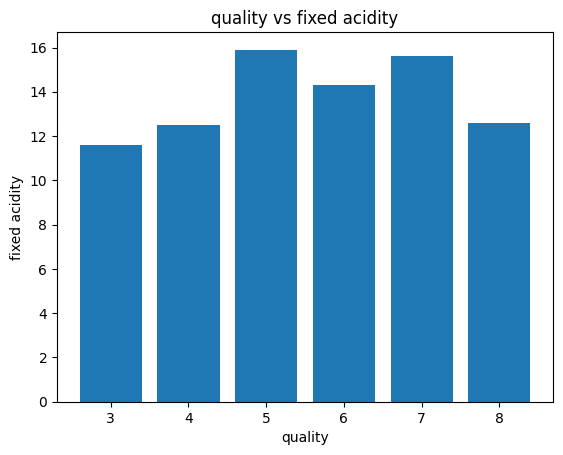

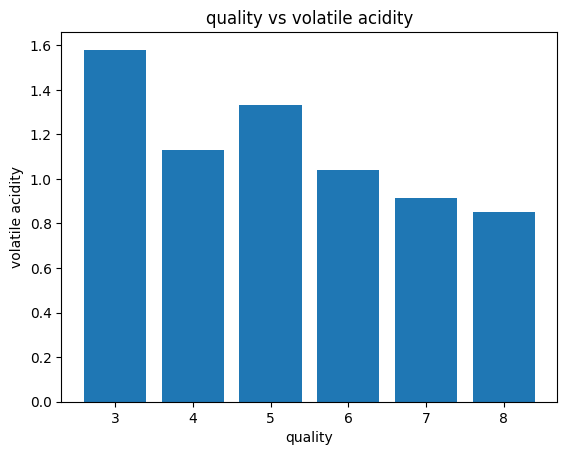

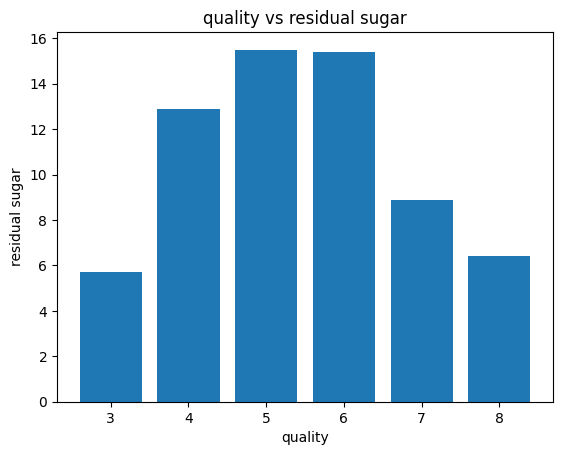

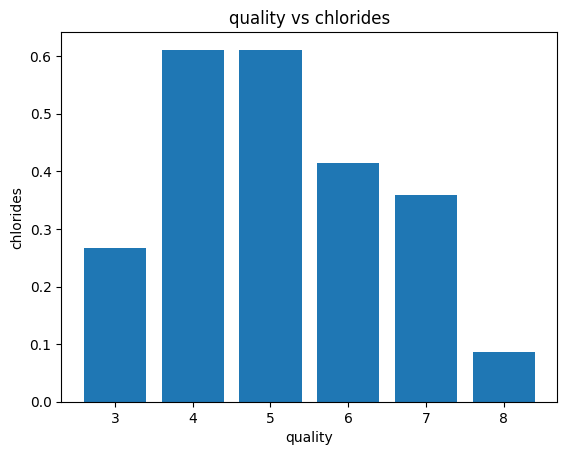

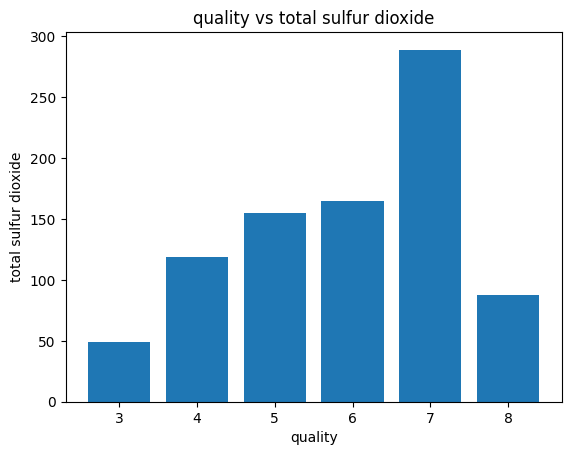

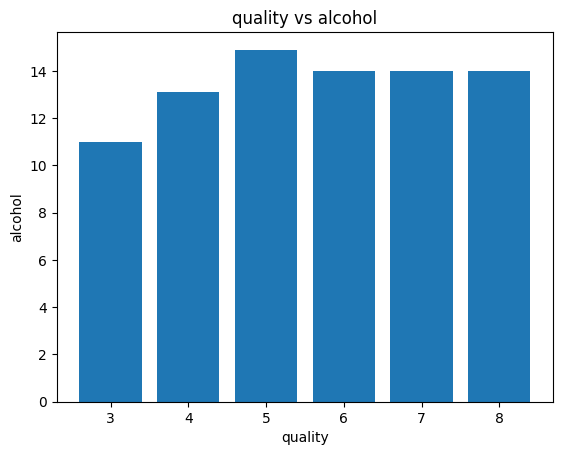

In [49]:
import matplotlib.pyplot as plt

def barplot_quality_vs_feature(feature_name: str):
    plt.bar(data["quality"], data[feature_name])
    plt.xlabel("quality")
    plt.ylabel(feature_name)
    plt.title(f"quality vs {feature_name}")
    plt.show()

barplot_quality_vs_feature("fixed acidity")
barplot_quality_vs_feature("volatile acidity")
barplot_quality_vs_feature("residual sugar")
barplot_quality_vs_feature("chlorides")
barplot_quality_vs_feature("total sulfur dioxide")
barplot_quality_vs_feature("alcohol")

## Correlation heatmap

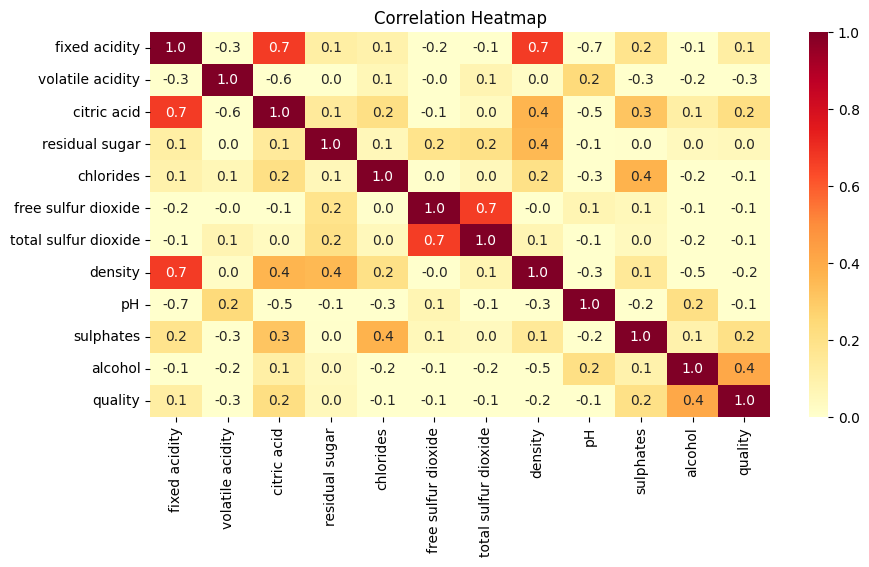

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(
    data.corr(),
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    vmin=0, vmax=1            # focuses on 0..1 so negatives look light and positives look darker
)
plt.title("Correlation Heatmap")
plt.show()

### This correlation heatmap tells you how strongly each feature moves with another feature (from -1 to +1):

+1 (positive): both increase together

-1 (negative): one increases, the other decreases

0: no linear relationship

### Most important thing: what relates to quality

### Look at the quality row/column:

- Alcohol vs Quality ≈ +0.5 → higher alcohol is associated with better quality (strongest positive here).
- Volatile acidity vs Quality ≈ -0.4 → higher volatile acidity is associated with lower quality (strongest negative here).
- Sulphates vs Quality ≈ +0.3 → sulphates moderately help quality.
- Citric acid vs Quality ≈ +0.2 → weak positive.
- Density vs Quality ≈ -0.2 → weak negative.
- Residual sugar ≈ 0.0 → basically no linear relationship with quality in this dataset.

### Also useful: relationships between features (multicollinearity hints)

Some features are strongly related to each other:

- Fixed acidity ↔ Citric acid ≈ +0.7
- Fixed acidity ↔ Density ≈ +0.7
- Free SO₂ ↔ Total SO₂ ≈ +0.7
- Fixed acidity ↔ pH ≈ -0.7 (more acidity → lower pH)

This matters because highly correlated features can be redundant (especially for linear models), and it’s one reason people sometimes use PCA.

### One warning!

Correlation ≠ causation. It only shows linear relationships.

## Binarization of target variable (quality)

In [234]:
data['quality'].unique() # unique values in quality/target variable --> we will map these 6 values to 1 or 0 --> good or bad quality wine using list comprehension

array([5, 6, 7, 4, 8, 3], dtype=int64)

In [236]:
data["quality"] = [1 if x >= 7 else 0 for x in data["quality"]]

In [238]:
data['quality'].unique() # all has been categorised into 0 or 1

array([0, 1], dtype=int64)

### Why I picked 7 ?

In practice:

- 3–6 is treated as average / not great
- 7–8 (and above) is treated as good / high quality

So quality >= 7 becomes a simple, common “good wine” threshold.

### Why 7 makes sense (practically)
- 7+ is clearly above average in this dataset’s range.
- It creates a binary classification problem (good vs bad) that’s easier for beginners than predicting the exact 3–8 score.

### But it’s not a “scientific law”

It’s a choice. I could choose:

- &gt;= 6 as good (less strict, more “good” samples)
- &gt;= 8 as good (very strict, very few “good” samples)
- Or keep it as multiclass (3,4,5,6,7,8) or regression (predict the score).

## Not Handling Imbalanced

In [240]:
data['quality'].value_counts() # quality is target variable (y)  , 1382 - bad wine  ,  217 - good wine

quality
0    1382
1     217
Name: count, dtype: int64

<Axes: xlabel='quality', ylabel='count'>

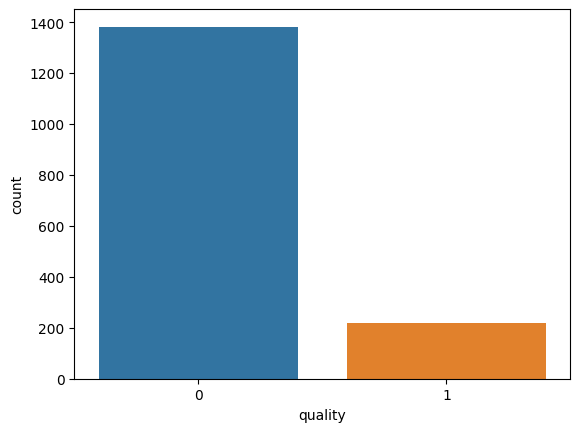

In [17]:
import seaborn as sns

sns.countplot(x="quality", data=data, palette=["tab:blue", "tab:orange"])

### Why to check if the target variable is imbalanced ?
Because Class imbalance completely changes how you should train and evaluate the model. Here 0 - Bad Wine is majority class and 1- Good wine is Miniority Class

### To avoid getting fooled by “high accuracy”
In this dataset, good wine cases are rare. If we don’t check imbalance, a model can predict Class = 0 for everything and still get ~99% accuracy—but it will catch 0 bad wine quality, which is useless.

### To choose the right evaluation metrics with imbalance, we must focus on:

- Recall (Fraud): how many frauds you actually catch

- Precision (Fraud): how many flagged frauds are truly fraud

- F1-score / PR-AUC (often better than ROC-AUC here)

### To decide if we need imbalance-handling methods

### Seeing imbalance tells us to use techniques like:

1. class_weight='balanced'

2. Under-sampling / Over-sampling (SMOTE)

3. Threshold tuning (not always 0.5)

4. Anomaly-detection style approaches (sometimes)

### Real-world reason
In wine quality detection, missing a good wine (false negative) is costly. So checking imbalance helps us design the model to prioritize catching good wine, not just being “mostly correct” on bad wine predictions.

## What if we don't handle this and directly store X and y ?

#### Store Feature Matrix In X And Response (Target) In Vector y

In [242]:
X = data.drop('quality',axis=1) # this will drop quality variable and store all other independent variables in X
y = data['quality'] # quality is the dependent Variable and is stored here in y----> 0-1382 , 1-217

In [244]:
X.shape # v1....v28 + Amount , 0-1382 , 1-217 = 1599

(1599, 11)

In [246]:
print(X.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')


In [248]:
y.shape

(1599,)

## Splitting The Dataset Into The Training Set And Test Set

In [250]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

# X = input/independent features (columns like fixed acidity, volatile acidity,residual sugar....)
# y = target/dependent /output you want to predict (here: quality = 0 or 1)
# X_train: features used to train/learn the model (80% rows)
# y_train: the correct answers (labels) for those training rows
# X_test: features kept aside to test the model (20% rows)
# y_test: the correct answers for those test rows (used only for evaluation)

### Feature Scaling

In [252]:
from sklearn.preprocessing import StandardScaler

In [254]:
print(data.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [174]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [256]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [258]:
X_train

array([[ 0.21833164,  0.88971201,  0.19209222, ...,  1.09349989,
         0.45822284,  1.12317723],
       [-1.29016623, -1.78878251,  0.65275338, ..., -0.40043872,
        -0.40119696,  1.40827174],
       [ 1.49475291, -0.78434707,  1.01104539, ..., -0.07566946,
         0.51551749, -0.58738978],
       ...,
       [-0.65195559,  0.49909822, -1.08752211, ...,  1.28836145,
        -0.68767023, -0.87248428],
       [-0.24582155, -1.84458448,  0.39683051, ...,  0.05423824,
         0.80199076,  1.40827174],
       [-1.46422367, -1.34236676, -0.06383064, ...,  0.50891521,
        -0.68767023,  2.92877575]])

In [260]:
X_test

array([[-3.61859850e-01,  1.64286407e-01, -9.85152962e-01, ...,
        -4.65392578e-01, -1.34389336e-04, -7.77452782e-01],
       [-3.03840702e-01, -1.70525408e-01, -5.24491803e-01, ...,
         5.08915214e-01, -1.03143815e+00, -8.72484283e-01],
       [ 1.37871461e+00,  7.78108067e-01, -2.68568937e-01, ...,
        -2.05577167e-01,  1.83329452e+00, -4.92358280e-01],
       ...,
       [-1.37449586e-02,  3.87494284e-01, -1.15015218e-01, ...,
        -1.04997725e+00, -7.44964886e-01, -5.87389780e-01],
       [ 2.76350785e-01, -1.45397070e+00,  6.01568807e-01, ...,
        -1.04997725e+00,  1.71749571e-01,  7.43051230e-01],
       [ 4.50408230e-01,  1.30822677e+00, -1.18989125e+00, ...,
        -1.40623314e-01, -6.87670232e-01, -6.82421281e-01]])

Why wine project scales full X, not just one column?

Because in wine data, all 11 features are on different scales (acidity, sugar, sulphur dioxide, alcohol, etc.). Scaling the whole X is useful, especially for models like SVM/KNN and for PCA.

## PCA (Principal Component Analysis)

In [262]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=0.90)  # (retain 90% variance)
X_train = pca.fit_transform(X_train)
X_test  = pca.transform(X_test)

print("\nPCA components:", X_train.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", np.sum(pca.explained_variance_ratio_))


PCA components: 7
Explained variance ratio: [0.2801769  0.17563995 0.13957636 0.11081822 0.09021248 0.05908698
 0.05266627]
Total variance retained: 0.9081771725271313


Input was 11 variables output is 7 , 7 components retaining 90% of information of our larger dataset

#### Why PCA was used in this project

1. Reduce features: Wine data has 11 input columns. PCA converts them into fewer principal components while keeping most information (they used n_components=0.90, meaning keep ~90% variance).

2. Speed + simplicity: Fewer features ⇒ faster training and sometimes a simpler model.

3. Helps distance-based models: For models like KNN and SVM, PCA can reduce noise/redundancy and sometimes improves performance after scaling.

4. Deals with correlated features: Many features are correlated (your heatmap shows that). PCA combines correlated variables into components, reducing redundancy.

#### Important note

For only 11 features, PCA is not strictly necessary. Many times Random Forest will work great without PCA. Tutorials often include PCA just to demonstrate the technique.

#### When PCA is a bad idea
- If you want interpretability (“which feature caused good quality?”), PCA makes it harder because components aren’t original features.
- If you’re using tree models (Decision Tree / Random Forest), PCA often gives little benefit and can even reduce performance.

## Logistic Regression (before sampling)

In [264]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(X_train,y_train)

LogisticRegression()

In [266]:
y_pred_bs = log.predict(X_test)

In [268]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred_bs)

#The model log has learned patterns from (X_train, y_train)

#Now I give it new/unseen inputs: X_test

#It outputs predicted classes for each row in X_test

0.853125

In [270]:
from sklearn.metrics import precision_score,recall_score,f1_score
precision_score(y_test,y_pred_bs) # precision

0.5

In [272]:
recall_score(y_test,y_pred_bs) # recall

0.2765957446808511

In [274]:
f1_score(y_test,y_pred_bs) # F1 Score

0.3561643835616438

1) **Accuracy = 0.853125**

**Meaning:** “Out of all wines, what fraction did the model classify correctly?”

**Why it can be misleading here:**
- Most wines belong to the **majority class (0 = bad quality)**.
- If the model predicts **0** most of the time, accuracy can still look high even if it performs poorly on **good wines (1)**.

---

2) **Precision (for class 1 = good wine) = 0.5**

**Meaning:** “When the model predicts **good wine (1)**, how often is it actually good?”

**Precision = 0.5 means:**
- Out of all wines predicted as **good**, only **~45.8%** are truly good.
- The remaining **~54.2%** are **false positives** (bad wines incorrectly labeled as good).

**Formula:**
$$
\mathrm{Precision}=\frac{TP}{TP+FP}
$$

---

3) **Recall (for class 1 = good wine) = 0.276**

**Meaning:** “Out of all truly **good wines (1)**, how many did the model correctly catch?”

**Recall = 0.234 means:**
- The model catches only **~23.4%** of actual good wines.
- It misses **~76.6%** of good wines → these are **false negatives (FN)** (good wines predicted as bad).

**Formula:**
$$
\mathrm{Recall}=\frac{TP}{TP+FN}
$$

---

4) **F1 Score (for class 1 = good wine) =0.356**

**Meaning:** A single score that balances **precision** and **recall**.

- If either precision or recall is low, **F1 will also be low**.

**Formula:**
$$
F_{1}=2\cdot\frac{\mathrm{Precision}\cdot\mathrm{Recall}}{\mathrm{Precision}+\mathrm{Recall}}
$$

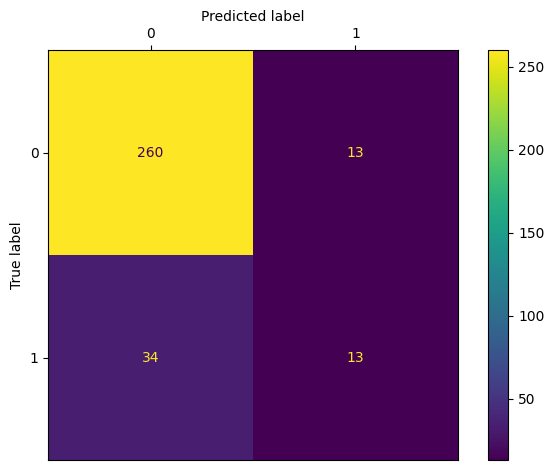

In [276]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1) Get confusion matrix
cm = confusion_matrix(y_test, y_pred_bs)   # default labels: [0, 1]
print("Confusion Matrix:\n", cm)

# 2) Pretty plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(values_format='d')
plt.show()

#### Why we use a confusion matrix (especially for fraud)

Accuracy alone hides the truth in imbalanced datasets. Confusion matrix shows exactly what kinds of mistakes our model is making:

#### What each number means

- TN = 260 (0 → 0): Bad wines correctly predicted as bad
- FP = 13 (0 → 1): Bad wines incorrectly predicted as good (false “good”)
- FN = 36 (1 → 0): Good wines incorrectly predicted as bad (missed good wines)
- TP = 11 (1 → 1): Good wines correctly predicted as good

#### Insights

- **Bad-wine recall (class 0):**  
  $$\text{Recall}_0 = \frac{260}{260 + 13} \approx 95.2\%$$

- **Good-wine recall (class 1):**  
  $$\text{Recall}_1 = \frac{11}{11 + 36} \approx 23.4\%$$

- **Precision for good (class 1):**  
  $$\text{Precision}_1 = \frac{11}{11 + 13} \approx 45.8\%$$

## Handling Imbalanced Dataset

- Undersampling : reduce the majority class by deleting some normal samples to balance with the minority class.
- Oversampling : increase the minority class by duplicating or synthetically generating fraud samples to balance with the majority class.

#### Oversampling
We lose a lot of useful data in Undersampling so we will go with Oversampling.

In [280]:
X = data.drop('quality',axis=1) # this will drop quality variable and store all other independent variables in X
y = data['quality'] # quality is the dependent Variable and is stored here in y----> 0-1382 , 1-217

##### SMOTE (Synthetic Minority Over-sampling Technique)

In [282]:
from imblearn.over_sampling import SMOTE

In [284]:
X_res,y_res = SMOTE().fit_resample(X,y)

✅ This balances the data…
❌ BUT it also creates synthetic points using all rows, including the rows that will later become your test set.

That means our test set now contains synthetic samples that were generated using information from the whole dataset.


In [206]:
y_res.value_counts() # target class which needs to be balanced --> result we see is same no of good and bad wine

quality
0    1382
1    1382
Name: count, dtype: int64

#### We will again feature scale all and apply pca again and then store in X and y , so run the steps for feature scaling

In [295]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_res,y_res,test_size=0.20, random_state=42)

In [297]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train) # FEATURE SCALING
X_test = sc.transform(X_test)

In [299]:
X_train

array([[ 4.82283505e-01, -1.34642867e+00,  4.17011310e-01, ...,
        -5.36637754e-01, -5.75440104e-01,  4.13095005e-01],
       [ 6.48878705e-01, -3.37780326e-01,  8.13237427e-01, ...,
        -6.05977478e-01, -3.45179864e-01,  6.47749476e-01],
       [ 7.08495074e-01,  2.41583471e+00, -3.67468404e-01, ...,
         7.49174629e-01, -1.94789327e-01,  2.62000475e-01],
       ...,
       [ 3.12732245e-01,  7.55729139e-01, -1.67502923e+00, ...,
        -8.22398567e-01, -4.48510602e-01, -4.38205871e-01],
       [-1.96105679e-01,  9.63242336e-01, -1.15200490e+00, ...,
        -7.07766036e-02,  3.12653222e-01, -5.76904560e-04],
       [-7.61481151e-01,  8.74308109e-01, -1.36121463e+00, ...,
         1.43246732e+00, -1.01938347e+00, -1.22593801e+00]])

In [301]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=0.90)  # (retain 90% variance)        # APPLYING PCA
X_train = pca.fit_transform(X_train)
X_test  = pca.transform(X_test)

print("\nPCA components:", X_train.shape[1])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", np.sum(pca.explained_variance_ratio_))


PCA components: 7
Explained variance ratio: [0.28951002 0.18710539 0.1431459  0.10664479 0.08491463 0.0587315
 0.04738332]
Total variance retained: 0.9174355609369901


## Logistic Regression (after sampling)

In [303]:
log = LogisticRegression()
log.fit(X_train,y_train)

LogisticRegression()

In [305]:
y_pred_as_lr_smote = log.predict(X_test)

In [307]:
accuracy_score(y_test,y_pred_as_lr_smote) # ACCURACY

0.8155515370705244

In [309]:
precision_score(y_test,y_pred_as_lr_smote) # PRECISION

0.7721088435374149

In [311]:
recall_score(y_test,y_pred_as_lr_smote) # RECALL

0.8664122137404581

In [313]:
f1_score(y_test,y_pred_as_lr_smote) # F1-SCORE

0.816546762589928

,Before,After
Accuracy,0.998925,0.901554
Precision,0.670588,0.946809
Recall,0.633333,0.864078
F1,0.651429,0.903553


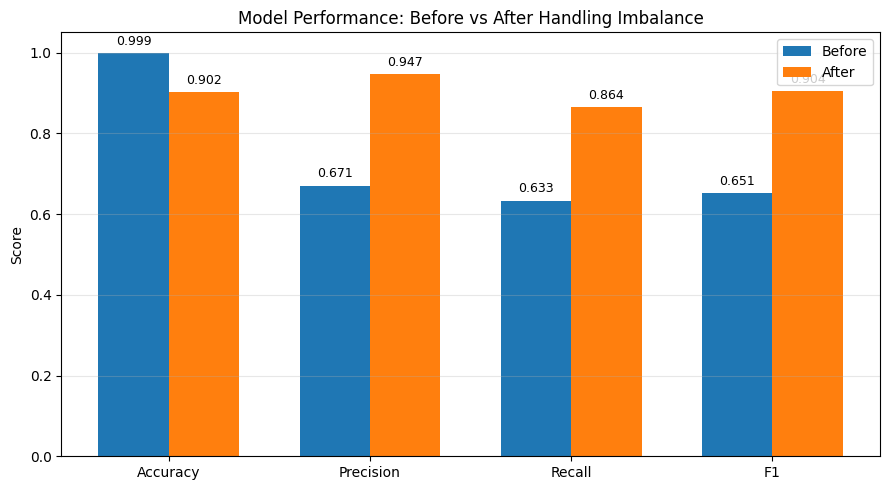

In [500]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----- YOUR METRICS -----
before = {  # before handling imbalance
    "Accuracy": 0.9989250343365555,
    "Precision": 0.6705882352941176,
    "Recall": 0.6333333333333333,
    "F1": 0.6514285714285714
}

after = {   # after handling imbalance
    "Accuracy": 0.9015544041450777,
    "Precision": 0.9468085106382979,
    "Recall": 0.8640776699029126,
    "F1": 0.9035532994923857
}

# ----- BUILD A SMALL TABLE -----
metrics = list(before.keys())
df = pd.DataFrame({
    "Before": [before[m] for m in metrics],
    "After":  [after[m] for m in metrics]
}, index=metrics)

display(df)

# ----- GROUPED BAR CHART -----
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, df["Before"], width, label="Before")
plt.bar(x + width/2, df["After"],  width, label="After")

plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Performance: Before vs After Handling Imbalance")
plt.legend()
plt.grid(axis="y", alpha=0.3)

# (Optional) value labels
for i, (b, a) in enumerate(zip(df["Before"], df["After"])):
    plt.text(i - width/2, b + 0.02, f"{b:.3f}", ha="center", fontsize=9)
    plt.text(i + width/2, a + 0.02, f"{a:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## SVC

In [322]:
from sklearn import svm

In [324]:
svm = svm.SVC()

In [326]:
svm.fit(X_train,y_train)

SVC()

In [328]:
y_pred_as_svc_smote = svm.predict(X_test)

In [330]:
accuracy_score(y_test,y_pred_as_svc_smote)

0.8788426763110307

In [332]:
precision_score(y_test,y_pred_as_svc_smote)

0.8421052631578947

In [334]:
recall_score(y_test,y_pred_as_svc_smote)

0.916030534351145

In [336]:
f1_score(y_test,y_pred_as_svc_smote)

0.8775137111517367

## K-Neighbours Classifier

In [340]:
from sklearn.neighbors import KNeighborsClassifier

In [342]:
knn = KNeighborsClassifier()

In [344]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [346]:
y_pred_as_knn_smote = knn.predict(X_test)

In [348]:
accuracy_score(y_test,y_pred_as_knn_smote)

0.8770343580470162

In [350]:
precision_score(y_test,y_pred_as_knn_smote)

0.803125

In [352]:
recall_score(y_test,y_pred_as_knn_smote)

0.9809160305343512

In [354]:
f1_score(y_test,y_pred_as_knn_smote)

0.8831615120274913

## Decision Tree

In [360]:
from sklearn.tree import DecisionTreeClassifier


In [362]:
dt = DecisionTreeClassifier()

In [364]:
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [368]:
y_pred_as_dt_smote = dt.predict(X_test)

In [370]:
accuracy_score(y_test,y_pred_as_dt_smote)

0.8698010849909584

In [372]:
precision_score(y_test,y_pred_as_dt_smote)

0.8298611111111112

In [374]:
recall_score(y_test,y_pred_as_dt_smote)

0.9122137404580153

In [376]:
f1_score(y_test,y_pred_as_dt_smote)

0.8690909090909091

## Random Forest

In [379]:
from sklearn.ensemble import RandomForestClassifier

In [381]:
rf = RandomForestClassifier()

In [383]:
rf.fit(X_train,y_train)

RandomForestClassifier()

In [385]:
y_pred_as_rf_smote = rf.predict(X_test)

In [387]:
accuracy_score(y_test,y_pred_as_rf_smote)

0.918625678119349

In [389]:
precision_score(y_test,y_pred_as_rf_smote)

0.8807017543859649

In [391]:
recall_score(y_test,y_pred_as_rf_smote)

0.9580152671755725

In [393]:
f1_score(y_test,y_pred_as_rf_smote)

0.9177330895795247

## Gradient Boosting

In [396]:
from sklearn.ensemble import GradientBoostingClassifier

In [398]:
gbc = GradientBoostingClassifier()

In [400]:
gbc.fit(X_train,y_train)

GradientBoostingClassifier()

In [402]:
y_pred_as_gb_smote = gbc.predict(X_test)

In [404]:
accuracy_score(y_test,y_pred_as_gb_smote)

0.8788426763110307

In [406]:
precision_score(y_test,y_pred_as_gb_smote)

0.8445229681978799

In [408]:
recall_score(y_test,y_pred_as_gb_smote)

0.9122137404580153

In [410]:
f1_score(y_test,y_pred_as_gb_smote)

0.8770642201834863

In [424]:
import pandas as pd
from sklearn.metrics import accuracy_score

final_data = pd.DataFrame({
    "Models": ["LR", "SVC", "KNN", "DT", "RF", "GBC"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_as_lr_smote) * 100,
        accuracy_score(y_test, y_pred_as_svc_smote) * 100,
        accuracy_score(y_test, y_pred_as_knn_smote) * 100,
        accuracy_score(y_test, y_pred_as_dt_smote) * 100,
        accuracy_score(y_test, y_pred_as_rf_smote) * 100,
        accuracy_score(y_test, y_pred_as_gb_smote) * 100,
    ]
})

final_data

,Models,Accuracy
0,LR,81.555154
1,SVC,87.884268
2,KNN,87.703436
3,DT,86.980108
4,RF,91.862568
5,GBC,87.884268


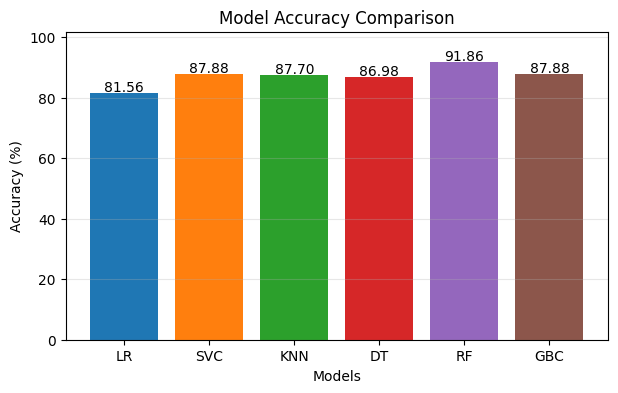

In [426]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

# Unique color per bar (auto)
colors = plt.cm.tab10(range(len(final_data)))   # tab10 gives 10 distinct colors

plt.bar(final_data["Models"], final_data["Accuracy"], color=colors)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

for i, v in enumerate(final_data["Accuracy"]):
    plt.text(i, v + 0.5, f"{v:.2f}", ha="center")

plt.ylim(0, final_data["Accuracy"].max() + 10)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Save The Model

In [433]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [429]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [431]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1594    0
1595    0
1596    0
1597    0
1598    0
Name: quality, Length: 1599, dtype: int64

In [435]:
X = data.drop('quality',axis=1) # this will drop quality variable and store all other independent variables in X
y = data['quality'] # quality is the dependent Variable and is stored here in y----> 0-1382 , 1-217

In [439]:
# 2) Apply SMOTE to balance classes
from imblearn.over_sampling import SMOTE
X_res, y_res = SMOTE().fit_resample(X, y)

In [441]:
X_res

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000
1,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000
2,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000
3,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000
4,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000
...,...,...,...,...,...,...,...,...,...,...,...
2759,9.275506,0.292709,0.438905,3.751011,0.097328,7.864556,16.432278,0.995578,3.258127,0.673285,12.102594
2760,7.800000,0.399193,0.312073,2.486789,0.094558,8.304587,17.304587,0.997162,3.339138,0.716037,10.543119
2761,10.471517,0.467385,0.608954,3.979077,0.080767,6.000000,18.563956,0.997666,3.211279,0.881859,12.789538
2762,8.999950,0.345028,0.420045,2.325138,0.057497,13.000000,27.000000,0.995080,3.290015,0.870015,12.550425


In [443]:
y_res

0       0
1       0
2       0
3       0
4       0
       ..
2759    1
2760    1
2761    1
2762    1
2763    1
Name: quality, Length: 2764, dtype: int64

In [449]:
# 3) Feature scaling
from sklearn.preprocessing import StandardScaler
st = StandardScaler()
X = st.fit_transform(X_res)

In [451]:
X_res

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000
1,7.800000,0.880000,0.000000,2.600000,0.098000,25.000000,67.000000,0.996800,3.200000,0.680000,9.800000
2,7.800000,0.760000,0.040000,2.300000,0.092000,15.000000,54.000000,0.997000,3.260000,0.650000,9.800000
3,11.200000,0.280000,0.560000,1.900000,0.075000,17.000000,60.000000,0.998000,3.160000,0.580000,9.800000
4,7.400000,0.700000,0.000000,1.900000,0.076000,11.000000,34.000000,0.997800,3.510000,0.560000,9.400000
...,...,...,...,...,...,...,...,...,...,...,...
2759,9.275506,0.292709,0.438905,3.751011,0.097328,7.864556,16.432278,0.995578,3.258127,0.673285,12.102594
2760,7.800000,0.399193,0.312073,2.486789,0.094558,8.304587,17.304587,0.997162,3.339138,0.716037,10.543119
2761,10.471517,0.467385,0.608954,3.979077,0.080767,6.000000,18.563956,0.997666,3.211279,0.881859,12.789538
2762,8.999950,0.345028,0.420045,2.325138,0.057497,13.000000,27.000000,0.995080,3.290015,0.870015,12.550425


In [453]:
# 4) PCA transform (assumes pca is already created earlier, e.g. pca = PCA(n_components=0.90))
X = pca.fit_transform(X)

In [459]:
X

array([[-1.95668273,  1.37873468, -1.91993848, ..., -0.13558405,
        -0.94795728, -0.28329618],
       [-1.31632159,  2.54765819, -0.48399624, ..., -0.04212772,
         0.26209085,  1.46245357],
       [-1.11836444,  1.7081061 , -1.08917278, ..., -0.11622234,
         0.03251355,  0.78930169],
       ...,
       [ 2.27651444, -1.34629107,  0.30607429, ...,  1.60006184,
        -0.3044698 ,  1.05597972],
       [ 0.4456194 , -2.00875777,  0.92119741, ...,  0.22513706,
        -0.38340985,  0.51924893],
       [ 2.14750014, -1.12550005, -0.25292084, ..., -0.35423703,
        -0.21308383,  0.06708152]])

In [461]:
# 5) Train Random Forest on full balanced data
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X, y_res)

RandomForestClassifier()

In [465]:
import joblib

joblib.dump(rf,"wine_quality_prediction")

['wine_quality_prediction']

In [467]:
model = joblib.load("wine_quality_prediction")

## Perform prediction on new unseen data

In [470]:
import pandas as pd

new_data = pd.DataFrame({
    "fixed acidity": 7.3,
    "volatile acidity": 0.65,
    "citric acid": 0.00,
    "residual sugar": 1.2,
    "chlorides": 0.065,
    "free sulfur dioxide": 15.0,
    "total sulfur dioxide": 21.0,
    "density": 0.9946,
    "pH": 3.39,
    "sulphates": 0.47,
    "alcohol": 10.0
}, index=[0])

new_data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.65,0.0,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0


In [472]:
test = pca.transform(st.transform(new_data))

In [474]:
p = model.predict(test)

p

array([1], dtype=int64)

In [476]:
if p[0] == 1:
    print("Good Quality Wine")
else:
    print("Bad Quality Wine")

Good Quality Wine


In [488]:
import pandas as pd

new_data_2 = pd.DataFrame({
    "fixed acidity": 8.8,
    "volatile acidity": 0.95,
    "citric acid": 0.02,
    "residual sugar": 2.6,
    "chlorides": 0.11,
    "free sulfur dioxide": 10.0,
    "total sulfur dioxide": 45.0,
    "density": 0.9986,
    "pH": 3.20,
    "sulphates": 0.45,
    "alcohol": 9.0
}, index=[0])

new_data_2

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,8.8,0.95,0.02,2.6,0.11,10.0,45.0,0.9986,3.2,0.45,9.0


In [492]:
test = pca.transform(st.transform(new_data_2))
p = model.predict(test)
print(p)  # expecting [0]
print("Bad Quality Wine" if p[0] == 0 else "Good Quality Wine")

[0]
Bad Quality Wine


“Bad Quality Wine (0)” (because it has high volatile acidity, low alcohol, relatively high chlorides, and higher density - patterns that usually relate to lower quality in this dataset).

#### Why “9.0 alcohol” isn’t automatically “high” and “0.11 chlorides” isn’t automatically “low”
- Alcohol is measured in % by volume (roughly 8–14 in this dataset).
- So 9.0% is actually on the lower side, not high.
- Chlorides are measured in a small decimal range (often around ~0.03 to 0.15).
- So 0.11 is actually relatively high for chlorides, even though it looks small.

#### So “high/low” only makes sense relative to that column’s normal range, not by looking at the absolute number.

#### Think of it like this
- Temperature: 30°C is high
- Money: $30 is not high
- Same number, different scale.

# GUI

In [480]:
from tkinter import *
from sklearn.preprocessing import StandardScaler
import joblib

In [498]:
def show_entry_fields():
    p1=float(e1.get())
    p2=float(e2.get())
    p3=float(e3.get())
    p4=float(e4.get())
    p5=float(e5.get())
    p6=float(e6.get())
    p7=float(e7.get())
    p8=float(e8.get())
    p9=float(e9.get()) 
    p10=float(e10.get())
    p11=float(e11.get())
    model = joblib.load('wine_quality_prediction')
    result=model.predict(pca.transform(st.transform([[p1,p2,p3,p4,p5,p6,
                           p7,p8,p9,p10,p11]])))
    
    if result[0] == 0:
        Label(master, text="Bad Quality Wine ❌").grid(row=31)
    else:
        Label(master, text="Good Quality Wine ✅").grid(row=31)
    
    
master = Tk()
master.title("Wine Quality Prediction by Aayush Gautam")


label = Label(master, text = "Wine Quality Prediction Using ML"
                          , bg = "black", fg = "white"). \
                               grid(row=0,columnspan=2)


Label(master, text="fixed acidity").grid(row=1)
Label(master, text="volatile acidity").grid(row=2)
Label(master, text="citric acid").grid(row=3)
Label(master, text="residual sugar").grid(row=4)
Label(master, text="chlorides").grid(row=5)
Label(master, text="free sulfur dioxide").grid(row=6)
Label(master, text="total sulfur dioxide").grid(row=7)
Label(master, text="density").grid(row=8)
Label(master, text="pH").grid(row=9)
Label(master, text="sulphates").grid(row=10)
Label(master,text="alcohol").grid(row=11)


e1 = Entry(master)
e2 = Entry(master)
e3 = Entry(master)
e4 = Entry(master)
e5 = Entry(master)
e6 = Entry(master)
e7 = Entry(master)
e8 = Entry(master)
e9 = Entry(master)
e10 = Entry(master)
e11 = Entry(master)



e1.grid(row=1, column=1)
e2.grid(row=2, column=1)
e3.grid(row=3, column=1)
e4.grid(row=4, column=1)
e5.grid(row=5, column=1)
e6.grid(row=6, column=1)
e7.grid(row=7, column=1)
e8.grid(row=8, column=1)
e9.grid(row=9, column=1)
e10.grid(row=10,column=1)
e11.grid(row=11,column=1)


Button(master, text='Predict', command=show_entry_fields).grid()

mainloop()